# `qab_vary_T.ipynb`: replica overlap $q_{ab}$ by temperature

In [2]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path

from utils.modelIO import *
from utils.overlaps import *

initialize

In [3]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
BIO_SIM_PATH = Path('results/eml/bio_vary_T/')
RAND_SIM_PATH = Path('results/eml/rand_vary_T/')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
temperatures = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

load data, using only 100 replicates so that memory use doesn't get too crazy

In [4]:
def load_bio_T(T):
    path = BIO_SIM_PATH.joinpath('bio_T_{:.0e}_xs.npy'.format(T))
    return jnp.load(path)[:, -1][:100]
bio_xs = jnp.array([load_bio_T(T) for T in temperatures])

# def load_rand_T(T):
#     path = RAND_SIM_PATH.joinpath('rand_T_{:.0e}_xs.npy'.format(T))
#     return jnp.load(path)[:, -1][:100]
# rand_xs = jnp.array([load_rand_T(T) for T in temperatures])

estimate $q_{ab}$

In [5]:
# vmap over temperatures
def get_all_qab_T(grn_states):
    return get_all_qab(grn_states, N)
get_all_qab_T_vmap = jax.vmap(get_all_qab_T)

In [6]:
bio_qabs = get_all_qab_T_vmap(bio_xs) # biological GRN
# rand_qabs = get_all_qab_T_vmap(rand_xs) # random networks

make violin plots

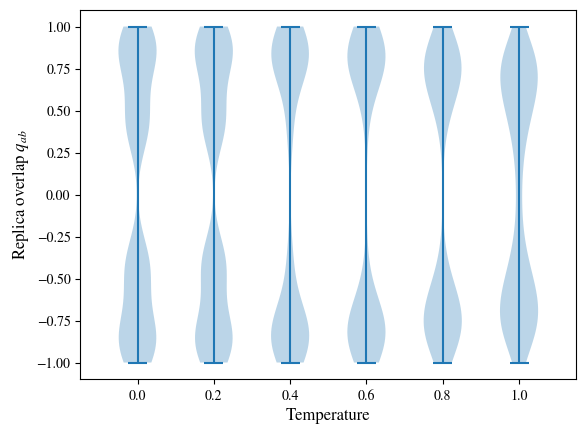

In [9]:
def set_axis_style(ax, labels):
    ax.set_xticks(jnp.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Temperature', fontsize=12)

fig, ax = plt.subplots()
ax.set_ylabel('Replica overlap $q_{ab}$', fontsize=12)
ax.violinplot(bio_qabs.T)
set_axis_style(ax, temperatures)
plt.savefig(FIG_SAVE_PATH.joinpath('qab_vary_T.pdf'), bbox_inches='tight')

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
# ax1.set_title('EMP fate network', fontsize=12)
# ax1.set_ylabel('Replica overlap $q_{ab}$', fontsize=12)
# ax2.set_title('Random networks', fontsize=12)
# ax1.violinplot(bio_qabs.T)
# ax2.violinplot(rand_qabs.T)
# for ax in [ax1, ax2]:
#     set_axis_style(ax, temperatures)
# plt.savefig(FIG_SAVE_PATH.joinpath('qab_vary_T.pdf'), bbox_inches='tight')